# 14 Text Classification

In [209]:
import sys

if "google.colab" in sys.modules:
    print("Running in Colab!")
    !pip install unidecode

In [498]:
import os
import shutil
import string
import random
import pathlib
import unidecode
import collections
import regex as re

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
from IPython.display import clear_output

from IPython.core.magic import register_cell_magic

os.environ["KERAS_BACKEND"] = "jax"

import keras

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

---

## A brief history of natural language processing

The **big** story of recent years has been a move away from **hand-crafted features**.

Well until the 1990s the industry employed many linguists to implement specialist knowledge into rules for NLP systems.

Then, statistical approaches took over, especially with the rise of deep learning.

We leave aside the question of exactly **what** current systems understand from language.

What we know is that we can now train them to take in pieces of text, execute task on them.

- "What’s the topic of this text?" (**text classification**)  
- "Does this text contain abuse?" (**content filtering**)  
- "Does this text sound positive or negative?" (**sentiment analysis**)  
- "What should be the next word in this incomplete sentence?" (**language modeling**)  
- "How would you say this in German?" (**translation**)  
- "How would you summarize this article in one paragraph?" (**summarization**)


## Preparing text data

### Overview

- **standardisation**: make your text easier to process
- **splitting** (**tokenisation**): split into chunks (= tokens)
- **indexing**: turn chunks into numbers (indices in a fixed *vocabulary*)

#### Note: Text encoding

The question of **how language is represented** in computers is an important topic: if you're interested in working with language, do go and learn this!

The [**The Unicode Standard**](https://en.wikipedia.org/wiki/Unicode) is a world-wide consensus to associate characters of all languages with a unique identifier (a number), called a **code point**.

The Python documentation on [Unicode](https://docs.python.org/3/howto/unicode.html).

**Code points** can then be **encoded** in bits ([**UTF-8**](https://en.wikipedia.org/wiki/UTF-8), 8 bits, is one of the ways you can do that, and is backward-compatible with [**ASCII**](https://en.wikipedia.org/wiki/ASCII), 7 bits).

The reference has a very nice video summary on UTF-8.

---

### Text standardization

- Convert to **lower case**;  
- Remove **punctuation**;
- Convert **special characters** to a standard form (é → e);
- *Stemming*: turn **inflected forms** into base ones ("stares"/"stared"/"staring" → "[stare]")

In [211]:
s = "I didn't wake up this morning. How did that happen?"

In [212]:
s.lower()

"i didn't wake up this morning. how did that happen?"

In [213]:
"".join(char for char in s.lower() if char not in string.punctuation) # removing punctuation

'i didnt wake up this morning how did that happen'

In [214]:
def str_to_ints(s):
    # encode into bytes, then turn into a list
    s_enc = s.encode()
    print(f"{s} | {s_enc} | {list(s_enc)}")
s = "Jérémie"
str_to_ints(s)
str_to_ints(s.lower())
# removing anything
str_to_ints(unidecode.unidecode(s.lower()))

Jérémie | b'J\xc3\xa9r\xc3\xa9mie' | [74, 195, 169, 114, 195, 169, 109, 105, 101]
jérémie | b'j\xc3\xa9r\xc3\xa9mie' | [106, 195, 169, 114, 195, 169, 109, 105, 101]
jeremie | b'jeremie' | [106, 101, 114, 101, 109, 105, 101]


---

### Text splitting (tokenization)

We will cover three very common schemes:

- **character-level tokenization**: split on characters;
- **word-level tokenization**: split on spaces;
- **subword tokenization**: split based on frequency of character clusters (can be characters, parts of words, words, phrases)

Note also:
- **n-gram tokenization**: tokenize using the scheme of your choice, then create groups of length `n` ('abcd' -> 'a,b,c,d' -> 'ab,'bc','cd';
- **byte-level tokenization**: split on bytes.

You will note the use of the [`regex`](https://pypi.org/project/regex/) ("REGular EXpression") module (an updated version of the default [`re`](https://docs.python.org/3/library/re.html) package in Python). Regular expressions are *very* useful for any text manipulation: tutorials [here](https://realpython.com/regex-python/), [here](https://realpython.com/regex-python-part-2/) and [here](https://docs.python.org/3/howto/regex.html))

In [215]:
s = "the quick brown fox jumps over the lazy dog"

In [216]:
def split_chars(text):
    # return re.findall(r".", text)
    # an order of magnitued faster...
    return list(text)

In [217]:
chars = split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]

['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [218]:
def split_words(text):
    # '\w' any "word character"
    # '+' appearing once or more
    # '|' or
    # [] any char inside the brackets (punctuation)
    return re.findall(r"\w+|[.,!?;]", text)

In [219]:
split_words("The quick brown fox jumped over the dog.")

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'dog', '.']

---

### Vocabulary indexing

From a dataset, we create a big table **associating each word with a number**.

We can also add special information like an index for:
- **unknown words** ("\[UNK\]" for *unknown*, aka OOV: out of vocabulary);
- **beginning of sentence** ("bos");
- **end of sentence** ("eos");
- **padding** ("\[PAD\]", to make sequences the same length);
- **masked token**, and other customised "special tokens" depending on needs...

In [220]:
vocabulary = {
    "[UNK]": 0,
    "the": 1,
    "quick": 2,
    "brown": 3,
    "fox": 4,
    "jumped": 5,
    "over": 6,
    "dog": 7,
    ".": 8,
}
words = split_words("The quick brown fox jumped over the lazy dog.")
indices = [vocabulary.get(word, 0) for word in words]

In [221]:
indices

[0, 2, 3, 4, 5, 6, 1, 0, 7, 8]

In [222]:
reverse_vocab = {v:k for k,v in vocabulary.items()}

print(" ".join([reverse_vocab[i] for i in indices]))

[UNK] quick brown fox jumped over the [UNK] dog .


The full pipeline:

<!-- <img style="height: 400px" src="images/chollet/figure14.1.png"> -->
<img style="height: 400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/07/images/chollet/figure14.1.png">

[DLWP](https://deeplearningwithpython.io/chapters/chapter14_text-classification/#preparing-text-data), Figure 14.1

### Types of tokenzation

#### Char tokenization

In this first example, we'll isolate every character in the text, and map that to one integer.

In [223]:
class CharTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        # an order of magnitude faster than using regex...
        return list(inputs)
        # return re.findall(r".", inputs)

    def index(self, tokens):
        # translate back into strings using our vocab, with '[UNK]' as fallback
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        # the standardization is to simplify things, but you could remove it as well
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [224]:
def compute_char_vocabulary(inputs, max_size):
    char_counts = collections.Counter()
    for x in inputs:
        # same optional standardization step as before
        x = x.lower()
        # an order of magnitude faster than using regex...
        tokens = list(x)
        # tokens = re.findall(r".", x)
        char_counts.update(tokens)
    vocabulary = ["[UNK]"]
    # get the most common minus 1 (we already have '[UNK]')
    most_common = char_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

#### Word tokenization

Then, if we use a different splitting method (on words – `\w+`, "one or more word character" in regex –, or any punctuation character), our vocabulary will be much larger, but the resulting encoding will be shorter

In [664]:
string.punctuation # the punctuation characters we isolate in the regex

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [225]:
class WordTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        # split into either words or punctuation signs ('[]' means match 'any of the characters inside')
        return re.findall(rf"\w+|[{string.punctuation}]", inputs)

    def index(self, tokens):
        # translate back into strings using our vocab, with '[UNK]' as fallback
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        # the standardization is to simplify things, but you could remove it as well
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [675]:
def compute_word_vocabulary(inputs, max_size):
    word_counts = collections.Counter()
    for x in inputs:
        # same optional standardization step as before
        x = x.lower()
        # split into either words or punctuation signs ('[]' means match 'any of the characters inside')
        tokens = re.findall(rf"\w+|[{string.punctuation}]", x)
        word_counts.update(tokens)
    vocabulary = ["[UNK]"]
    if max_size > 0:
        # get the most common minus 1 (we already have '[UNK]')
        most_common = word_counts.most_common(max_size - len(vocabulary))
    else:
        # get everything
        most_common = word_counts.most_common()
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

#### Test our tokenizers so far

Here we use Melville's [Moby Dick](https://www.gutenberg.org/ebooks/2701), but feel free to try other texts as well!

[`keras.utils.get_file` documentation](https://keras.io/api/utils/python_utils/#getfile-function)

In [668]:
filename = keras.utils.get_file(
    origin="https://www.gutenberg.org/cache/epub/2701/pg2701.txt",
)

with open(filename, "r") as i:
    moby_dick = list(i)

##### Char tokenizer

Small vocabulary, longer encoding!

In [669]:
vocabulary = compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer = CharTokenizer(vocabulary)

In [670]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 79


In [671]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']


In [672]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['ח', 'ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â', '%']


In [673]:
print("Line length:", len(char_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 63


##### Word tokenizer

Large vocabulary, but shorter encoding!

In [682]:
# you could try max_size=0: even larger vocab, although for the example sentence below it wouldn't change anything
vocabulary = compute_word_vocabulary(moby_dick, max_size=2_000)
word_tokenizer = WordTokenizer(vocabulary)

In [683]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [684]:
print("Vocabulary start:", list(vocabulary.keys())[:5])

Vocabulary start: ['[UNK]', ',', 'the', '.', 'of']


In [685]:
print("Vocabulary end:", list(vocabulary.keys())[-5:])

Vocabulary end: ['barbaric', 'helmsman', 'temporary', 'indispensable', 'fashion']


In [686]:
print("Line length:", len(word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 13


#### Subword tokenization

In [627]:
data = [
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]

In [628]:
def count_and_split_words(data, apply_standardization=False):
    counts = collections.Counter()
    for line in data:
        # in production system, no standardization is applied!
        if apply_standardization:
            line = line.lower()
        # for each match (a word or a punctuation sign)
        for match in re.finditer(rf"\w+|[{string.punctuation}]", line):
            word = match.group()
            start = match.start()
            # ignore the beginning of the string, then if char at start is preceded by space, create prefix
            prefix = "Ġ" if start > 0 and line[start - 1].isspace() else ""            
            # decompose into chars
            # chars = re.findall(r".", word)
            # decompose into chars (list(word)), but include the prefix with the first char
            chars = ([prefix + word[0]] + list(word[1:])) if word else []
            # rejoin into a string with spaces between
            split_word = " ".join(chars)
            # add the split word to the counter
            counts[split_word] += 1

            # print(f"{match=} | {word=} | {chars=}")
            
    return dict(counts)

counts = count_and_split_words(data)

In [629]:
counts

{'t h e': 3,
 'Ġq u i c k': 2,
 'Ġb r o w n': 3,
 'Ġf o x': 2,
 'Ġs l o w': 1,
 'Ġf o x h o u n d': 1}

In [630]:
def count_pairs(counts):
    # create a counter for pairs of symbols
    pairs = collections.Counter()
    # for all words
    for word, freq in counts.items():
        # split on space -> symbols (chars or char groups)
        symbols = word.split()
        # each time a pair of symbols appears, add the frequency of the word it appears in
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pair(counts, first, second):
    # regex:
    # - (?<!A)B find B if not (!) preceded (<) by A 
    # - A(?!B) find A if not (!) preceding B
    # for first=ab, second=cd, will match a string
    # with [any space]ab cd[any space], so
    # '... ab cd ...', but not '...ab cd...'
    # (the double \\ is required to escape – make valid – the \)
    split = re.compile(fr"(?<!\S){first} {second}(?!\S)")
    merged = f"{first}{second}"
    # we find 'X ab cd Y', and substitute it with 'X abcd Y', in all words
    return {split.sub(merged, word): count for word, count in counts.items()}

In [631]:
# the number 5 is arbitrary:
counts_bpe = counts.copy()
for i in range(5):
    
    pairs = count_pairs(counts_bpe)
    # first, second = max(pairs, key=pairs.get)  
    [(first, second), freq] = pairs.most_common(n=1)[0]
    
    print(f"{i+1} | merging: {first} {second} → {first}{second} ({freq} occurrences)")
    print()
    print(f"{list(counts_bpe.keys())}")

    counts_bpe = merge_pair(counts_bpe, first, second)

    print(f"{list(counts_bpe.keys())}")
    print()
    print("-" * 20)
    print()

1 | merging: o w → ow (4 occurrences)

['t h e', 'Ġq u i c k', 'Ġb r o w n', 'Ġf o x', 'Ġs l o w', 'Ġf o x h o u n d']
['t h e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

2 | merging: t h → th (3 occurrences)

['t h e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['th e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

3 | merging: th e → the (3 occurrences)

['th e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

4 | merging: Ġb r → Ġbr (3 occurrences)

['the', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq u i c k', 'Ġbr ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

5 | merging: Ġbr ow → Ġbrow (3 occurrences)

['the', 'Ġq u i c k', 'Ġbr ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq

In [632]:
def compute_sub_word_vocabulary(dataset, n_merges, apply_standardization=True):
    counts = count_and_split_words(dataset, apply_standardization=apply_standardization)

    char_counts = collections.Counter()
    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]
    most_common = char_counts.most_common()
    # add the unknown token at the star
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    v_l = len(vocab)
    print(f"vocab size before merging: {v_l}")
    
    merges = []

    # continue merging until we have either merged everything or reached our vocab size
    while len(vocab) < n_merges:
        pairs = count_pairs(counts)
        if not pairs:
            break
        # find the most frequent pair
        first, second = max(pairs, key=pairs.get)
        # merge the pair in all words
        counts = merge_pair(counts, first, second)
        # append the merged pair as token,
        vocab.append(f"{first}{second}")
        # and the merge itself (we need that to decode!)
        merges.append(f"{first} {second}")

        clear_output(wait=True)
        print(f"vocab size before merging: {v_l}")
        print(f"{len(vocab)}/{n_merges}")
    else:
        print(f"vocab size now: {len(vocab)}")

    vocab = dict((token, index) for index, token in enumerate(vocab))
    # note the 'rank': the most frequent merge comes first in our list
    merges = dict((token, rank) for rank, token in enumerate(merges))
    return vocab, merges

In [633]:
apply_standardization=True
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2000, apply_standardization=apply_standardization)

vocab size before merging: 162
2000/2000
vocab size now: 2000


In [634]:
print("Vocabulary length:", len(vocabulary))
print("Vocabulary start:", list(vocabulary.keys())[:10])
print("Vocabulary end:", list(vocabulary.keys())[-7:])

Vocabulary length: 2000
Vocabulary start: ['[UNK]', 'e', 'n', 'o', 'a', 't', 'i', 'h', 'r', 's']
Vocabulary end: ['Ġshow', 'Ġwondrous', 'Ġgun', 'Ġencoun', 'Ġcopy', 'ĠChrist', 'keleton']


In [635]:
print("Merges length:", len(merges))
print("Merges start:", list(merges.keys())[:10])
print("Merges end:", list(merges.keys())[-7:])

Merges length: 1838
Merges start: ['h e', 'Ġt he', 'i n', 'e r', 'n d', 'a t', 'e d', 'in g', 'r e', 'o u']
Merges end: ['Ġsh ow', 'Ġwond rous', 'Ġg un', 'Ġen coun', 'Ġcop y', 'ĠCh rist', 'kelet on']


In [641]:
class SubWordTokenizer:
    def __init__(self, vocabulary, merges, apply_standardization=True):
        self.vocabulary = vocabulary
        self.invert_vocab = {v:k for k, v in self.vocabulary.items()}
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]
        self.apply_standardization = apply_standardization

    def standardize(self, inputs):
        return inputs.lower()

    def bpe_merge(self, word):
        while True:
            # Matches all symbol pairs in the text
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)
            if not pairs:
                break
            # We apply merge rules in "rank" order. More frequent pairs
            # are merged first → they have the lowest rank               
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))
            if best not in self.merges:
                break
            first, second = best.split()
            split = re.compile(rf"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)
        return word

    def split(self, inputs):
        tokens = []
        # Split words        
        for match in re.finditer(rf"\w+|[{string.punctuation}]", inputs):
            word = match.group()
            start = match.start()
            # ignore the beginning of string, then: if first match char is preceded by space, create prefix            
            prefix = "Ġ" if start > 0 and inputs[start - 1].isspace() else ""        
            # decompose into chars (list(word)), but include the prefix with the first char
            word = " ".join([prefix + word[0]] + list(word[1:]))        
            # Applies byte-pair encoding merge rules            
            word = self.bpe_merge(word)
            tokens.extend(word.split())
        return tokens

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        if self.apply_standardization:
            inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

    def detokenize(self, token_ids):
        # we assume here that "Ġ" only appears as a substitute of space...
        return "".join(self.invert_vocab[i] for i in token_ids).replace("Ġ", " ")

In [642]:
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges, apply_standardization=apply_standardization)

In [663]:
tokenized_s = sub_word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)
print(tokenized_s)
print("Line length:", len(tokenized_s))

[63, 241, 289, 45, 485, 1568, 273, 29, 49, 269, 1090, 363, 3, 44, 44, 2, 393, 1094, 559, 476, 1376, 530, 193, 29]
Line length: 24


In [644]:
sub_word_tokenizer.detokenize(tokenized_s)

'Call me Ishmael. Some years ago--never mind how long precisely.'

Note that an important piece of the pipeline is missing: in production versions of BPE, the tokenizer computes the merges on raw bytes, and always includes, as a 'backup', the minimal 256 tokens vocabulary (all possibilities for one byte), which means that in the worst case, it will always be able to encode/decode sequences without resorting to '[UNK]'. See the reference notebook for ressources to learn more about this!

---

### Using the TextVectorization layer

Documentation for [`keras.layers.TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/)

In [249]:
text_vectorization = keras.layers.TextVectorization(
    # returns a sequence of integers
    output_mode="int"
)

I0000 00:00:1770823178.954579 14281854 service.cc:152] XLA service 0x6000033f4f00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770823178.954783 14281854 service.cc:160]   StreamExecutor device (0): Host, Default Version


In [250]:
dataset = [
    "I write, erase, rewrite",
    "Erase again, and then",
    "A poppy blooms.",
]                # ↓ the `adapt()` method is the equivalent to the `fit()` one for models
text_vectorization.adapt(dataset)

In [251]:
vocabulary = text_vectorization.get_vocabulary()
print(vocabulary) # displaying the vocabulary

['', '[UNK]', np.str_('erase'), np.str_('write'), np.str_('then'), np.str_('rewrite'), np.str_('poppy'), np.str_('i'), np.str_('blooms'), np.str_('and'), np.str_('again'), np.str_('a')]


In [252]:
test_sentence = "I write, rewrite, and still rewrite again"
encoded_sentence = text_vectorization(test_sentence)
print(encoded_sentence)

tf.Tensor([ 7  3  5  9  1  5 10], shape=(7,), dtype=int64)


In [253]:
inverse_vocab = dict(enumerate(vocabulary))
decoded_sentence = " ".join(inverse_vocab[int(i)] for i in encoded_sentence)
print(decoded_sentence) # 'still' was not present in the original corpus (our three sentences)

i write rewrite and [UNK] rewrite again


**Note**

How do you customize such a layer? You can pass user-defined functions to it.

(Documentation for the [`tf.strings`](https://www.tensorflow.org/api_docs/python/tf/strings) module)  

In [254]:
def custom_standardization_fn(string_tensor):
    """Standardize string tensor using regex (REGular EXpressions)"""
    lowercase_string = tf.strings.lower(string_tensor)               # to lower case
    return tf.strings.regex_replace(
        lowercase_string, f"[{re.escape(string.punctuation)}]", ""   # remove all punctuation
    )

def custom_split_fn(string_tensor):
    """Split string tensor"""
    return tf.strings.split(string_tensor)                           # split on spaces

text_vectorization = keras.layers.TextVectorization(
    output_mode="int",
    standardize=custom_standardization_fn, # apply special functions to
    split=custom_split_fn,                 # standardize and split
)

---

## Sets vs sequences

- Sets: "bag of words", the order is lost.  
- Sequences: order/time matters!

### Preparing the IMDB movie reviews data

#### Downloading the data & organise the directory

In [255]:
DATASET_DIR = pathlib.Path("aclImdb")

if not DATASET_DIR.exists():
    !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz # this untars the archive to a folder called aclImdb
    !rm -r aclImdb/train/unsup

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

In [256]:
!cat aclImdb/train/pos/4077_10.txt

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy

In [257]:
# code to split the data into train/val folders

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"
for category in ("neg", "pos"):
    if not os.path.isdir(VAL_DIR / category):    # do this only once
        os.makedirs(VAL_DIR / category)          # make 'neg'/'pos' dir in validation
        files = os.listdir(TRAIN_DIR / category) # list files in 'train'
        random.Random(1337).shuffle(files)       # shuffle using a seed
        num_val_samples = int(0.2 * len(files))  # 2% of our samples for validation
        val_files = files[-num_val_samples:]
        for fname in val_files:                  # move our files
            shutil.move(TRAIN_DIR / category / fname,
                        VAL_DIR / category / fname)

#### Process using `text_dataset_from_directory`

See the [documentation](https://keras.io/api/data_loading/text/) (similar Keras helper functions to create a [Tensorflow Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) as `image_dataset_from_directory` we've seen).


In [258]:
BATCH_SIZE = 32

# each of these iterables returns tuples containing two tensors:
# samples, shape: (batch_size, sample_shape) ← our texts
# targets, shape: (batch_size,)              ← 0 or 1
train_ds = keras.utils.text_dataset_from_directory(
    TRAIN_DIR, batch_size=BATCH_SIZE
)
val_ds = keras.utils.text_dataset_from_directory(
    VAL_DIR, batch_size=BATCH_SIZE
)
test_ds = keras.utils.text_dataset_from_directory(
    TEST_DIR, batch_size=BATCH_SIZE
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [259]:
for inputs, targets in train_ds:            # displaying the shapes and dtypes of the first batch
    print("inputs.shape:", inputs.shape)
    print("inputs.dtype:", inputs.dtype)
    print("targets.shape:", targets.shape)
    print("targets.dtype:", targets.dtype)
    print()
    print("targets[0]:", targets[0].numpy())
    print()
    print("inputs[0]:", inputs[0].numpy())
    break

inputs.shape: (32,)
inputs.dtype: <dtype: 'string'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>

targets[0]: 0

inputs[0]: b'OK I had higher hopes for this Carnosaur movie simply because it seemed like the sequels were getting better as they came out. I did like Carnosaur 2 better than 1. I figured well this one is newer so it must be better right? Well... I quickly learned I was wrong. I was extremely confused with the casting. They brought back Rick Dean for another spotlight character and Michael MacDonald as a police officer. Now for Rick dean lol, in Carnosaur 2 I thought he fit the role pretty well and wasn\'t really annoyed by him, now in Carnosaur 3 wow they placed him as an elite soldier. Now we are getting goofy here. The movie actually started out pretty good with a decent gun fight and dinos escaping out of there little freezer trucks, but as soon as Scott Valentines team showed up we had a mix of a romantic comedy with very funny performances from retarded and flo

---

## Set models

#### Bag-of-words (unigrams), multi-hot encoding

- bag-of-word (unigram): first you split, then take each split on its own
- binary encoding: multi-hot
- the order is lost

The same set-up as when dealing with IMDB before (we did it manually then).

In [260]:
max_tokens = 20_000
# preprocessing our datasets with a `TextVectorization` layer
text_vectorization = keras.layers.TextVectorization(
    # cap the vocab size to 20k
    max_tokens=max_tokens,
    # a 1 at the index of each word present, 0 otherwise
    output_mode="multi_hot",
    # the default
    split="whitespace",
)

##### BOW tests

In [261]:
# unigram == bag of words (BOW)
set("the cat sat on the mat".split())

{'cat', 'mat', 'on', 'sat', 'the'}

In [262]:
text_only_train_ds = train_ds.map(lambda x, y: x)
text_vectorization.adapt(text_only_train_ds)

In [263]:
vocabulary = text_vectorization.get_vocabulary()
inverse_vocab = dict(enumerate(vocabulary))

In [264]:
cat = text_vectorization("the cat")
print(cat.numpy(), cat.shape)                                    # "the cat" is now a vector of 20000 zeros
                                                                 #  with 1s at the index of "the" and "cat"
print()
indz = tf.where(cat > 0)                                         # retrieving the indices of the words
print(indz.numpy())
print()
print(" ".join([inverse_vocab[i.numpy().item()] for i in indz])) # retranslating back into a string

[0 1 0 ... 0 0 0] (20000,)

[[   1]
 [1162]]

the cat


In [265]:
cat = text_vectorization("the cute cat")
print(cat.numpy(), cat.shape)
print()
indz = tf.where(cat > 0)
print(indz.numpy())
print()
print(" ".join([inverse_vocab[i.numpy().item()] for i in indz]))

[0 1 0 ... 0 0 0] (20000,)

[[   1]
 [1061]
 [1162]]

the cute cat


---

### Training a bag-of-words model

In [266]:
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)

In [267]:
for inputs, targets in bag_of_words_train_ds: # inspecting the output of our binary unigram dataset
    print("inputs.shape:", inputs.shape)
    print("inputs.dtype:", inputs.dtype)
    print("targets.shape:", targets.shape)
    print("targets.dtype:", targets.dtype)
    print()
    print("targets[0]:", targets[0].numpy())
    print()
    print("inputs[0]:", inputs[0].numpy())
    break

inputs.shape: (32, 20000)
inputs.dtype: <dtype: 'int64'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>

targets[0]: 0

inputs[0]: [0 1 1 ... 0 0 0]


In [270]:
def build_linear_classifier(max_tokens, name, clear=True):
    """
    Our model-building utility
    """
    if clear:
        keras.backend.clear_session()
    inputs = keras.Input(shape=(max_tokens,))
    outputs = keras.layers.Dense(1, activation="sigmoid")(inputs)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",
        # our labels are only 0 or 1 (negative/positive)
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [274]:
# Training the binary unigram model
model = build_linear_classifier(max_tokens, "bag_of_words_classifier")
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [275]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)

history = model.fit(
    bag_of_words_train_ds.cache(),
    validation_data=bag_of_words_val_ds.cache(),
    epochs=10,
    callbacks=[early_stopping],
    verbose=0,
)

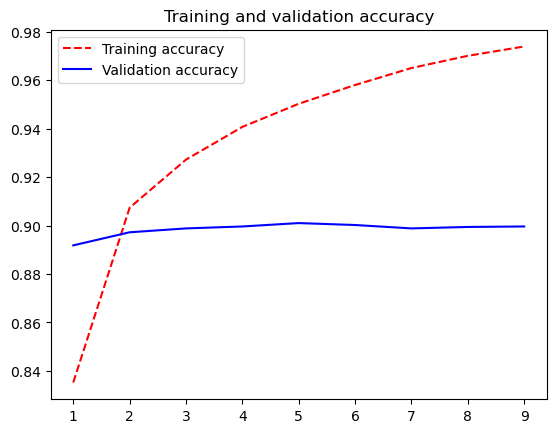

In [278]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [279]:
# And testing it
_, test_acc = model.evaluate(bag_of_words_test_ds)
print(f"Test acc: {test_acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8882 - loss: 0.2815
Test acc: 0.888


In [280]:
del (
    model, text_vectorization,
    bag_of_words_train_ds, bag_of_words_val_ds, bag_of_words_test_ds
)

----

### Training a bigram model

- bigram: first you split, then take tokens two by two   
- binary encoding: multi-hot (each bigram is one token!)
- *almost all* order is lost

In [289]:
max_tokens = 30_000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    split="whitespace",
    # returns bigrams
    ngrams=2,    
)

text_vectorization.adapt(text_only_train_ds)

# prepare our datasets
bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

In [290]:
vocabulary = text_vectorization.get_vocabulary()
print(f"{len(vocabulary)} tokens in the vocabulary")
# displaying the vocabulary
print([x.item() for x in vocabulary[100:108]])

30000 tokens in the vocabulary
['how', 'most', 'him', 'dont', 'it was', 'one of', 'then', 'for the']


In [291]:
encoded_sentence = text_vectorization("I write, rewrite, and still rewrite again")
print(encoded_sentence)

tf.Tensor([1 0 1 ... 0 0 0], shape=(30000,), dtype=int64)


In [284]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [285]:
# Training the binary bigram model
model = build_linear_classifier(max_tokens, "bigram_classifier")

history = model.fit(
    bigram_train_ds.cache(),
    validation_data=bigram_val_ds.cache(),
    epochs=10,
    callbacks=[early_stopping],
    verbose=0,
)

In [286]:
#  and testing
_, test_acc = model.evaluate(bigram_test_ds)
print(f"Test acc: {test_acc:.3f}") # better than the unigram model

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8965 - loss: 0.3092
Test acc: 0.896


In [287]:
del (
    model, text_vectorization,
    bigram_train_ds, bigram_val_ds, bigram_test_ds
)

---

## Summary

### NLP

- **standardisation** / **tokenisation** / **indexing**
- tokenisation: various possible **levels** (words, characters, n-grams, etc.)

- **Two kinds of NLP models**:
  - **bag-of-words** sets of words or n-grams, the order is lost.
  - **sequence models** that process word order.